<a href="https://colab.research.google.com/github/hiroki1982/Research/blob/main/POD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

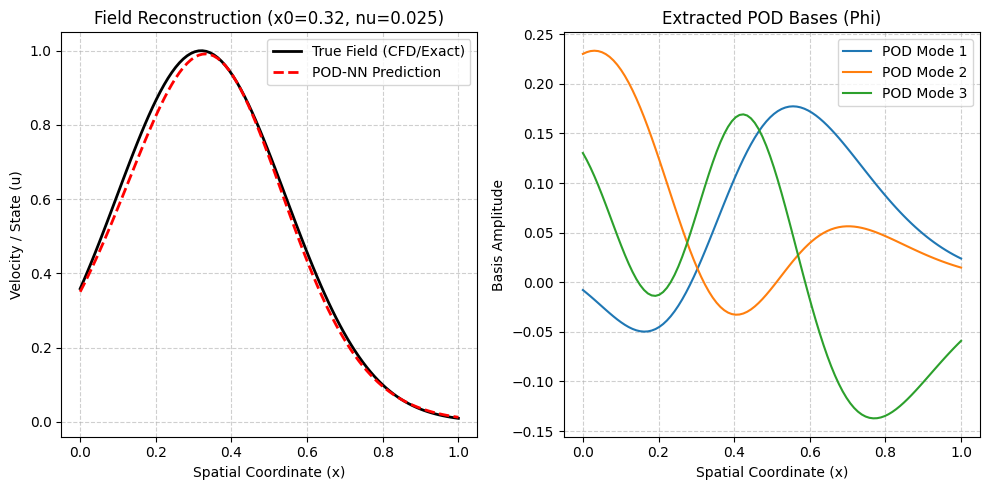

In [ ]:
# Jupyter Notebook用マジックコマンド（グラフのインライン表示）
%matplotlib inline

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

# ==========================================
# 1. サンプルデータ（流体場）の生成
# ==========================================
np.random.seed(42)
torch.manual_seed(42)

# 空間と時間の定義
x = np.linspace(0, 1, 100)  # グリッド数 N_grid = 100
n_samples = 150             # サンプル数 N_samples = 150

# パラメータ: 波の初期位置 (x0) と 拡散速度 (nu)
x0_list = np.random.uniform(0.2, 0.4, n_samples)
nu_list = np.random.uniform(0.01, 0.05, n_samples)
params = np.column_stack([x0_list, nu_list]).astype(np.float32)

# 簡易的な波の伝播データ（スナップショット行列 U: 150 x 100）
# U_i(x) = exp(-((x - x0)^2) / (4 * nu))
snapshots = np.zeros((n_samples, len(x)), dtype=np.float32)
for i in range(n_samples):
    snapshots[i, :] = np.exp(-((x - x0_list[i])**2) / (4 * nu_list[i]))

# ==========================================
# 2. POD（SVD）による次元削減
# ==========================================
# 平均場の引き算（前処理）
mean_field = np.mean(snapshots, axis=0)
snapshots_centered = snapshots - mean_field

# POD基底の抽出（上位 K=4 モードに圧縮）
K = 4
svd = TruncatedSVD(n_components=K, random_state=42)
a_true = svd.fit_transform(snapshots_centered)  # 正解のPOD係数 (150 x 4)
Phi = svd.components_.T                          # POD空間基底   (100 x 4)

# ==========================================
# 3. NN (PyTorch) の構築と学習
# ==========================================
class PODNN(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(PODNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
            nn.Linear(32, out_dim)
        )
    def forward(self, p):
        return self.net(p)

# データ変換
X_train = torch.from_numpy(params)
y_train = torch.from_numpy(a_true.astype(np.float32))

model = PODNN(in_dim=2, out_dim=K)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# 高速トレーニング（500 Epoch）
model.train()
for epoch in range(500):
    optimizer.zero_grad()
    pred_a = model(X_train)
    loss = criterion(pred_a, y_train)
    loss.backward()
    optimizer.step()

# ==========================================
# 4. 未知のパラメータでの推論と可視化
# ==========================================
model.eval()

# 未知のテストパラメータ (x0=0.32, nu=0.025)
test_param_val = np.array([[0.32, 0.025]], dtype=np.float32)
test_param_tensor = torch.from_numpy(test_param_val)

# 正解値（厳密解）
true_field = np.exp(-((x - 0.32)**2) / (4 * 0.025))

# POD-NN による推論
with torch.no_grad():
    pred_a = model(test_param_tensor).numpy()

# 物理場の復元: U_rec = a * Phi^T + Mean
reconstructed_field = np.dot(pred_a, Phi.T) + mean_field

# --- グラフ描画 ---
plt.figure(figsize=(10, 5))

# 1. 物理場の比較グラフ
plt.subplot(1, 2, 1)
plt.plot(x, true_field, 'k-', label='True Field (CFD/Exact)', linewidth=2)
plt.plot(x, reconstructed_field[0], 'r--', label='POD-NN Prediction', linewidth=2)
plt.title('Field Reconstruction (x0=0.32, nu=0.025)')
plt.xlabel('Spatial Coordinate (x)')
plt.ylabel('Velocity / State (u)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. 抽出されたPOD基底 (上位3モード)
plt.subplot(1, 2, 2)
for k in range(3):
    plt.plot(x, Phi[:, k], label=f'POD Mode {k+1}')
plt.title('Extracted POD Bases (Phi)')
plt.xlabel('Spatial Coordinate (x)')
plt.ylabel('Basis Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()